In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("telecomX_limpio.csv")

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,no,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,no,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [4]:
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

In [5]:
df = df.dropna()

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
df['Churn_yes'].value_counts()

,count
Churn_yes,
False,5163
True,1869


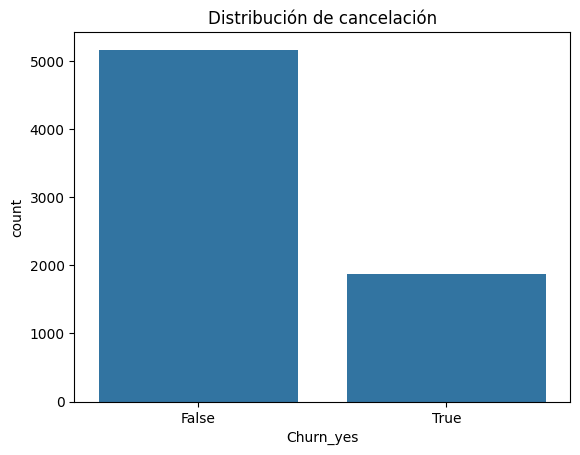

In [8]:
sns.countplot(x='Churn_yes', data=df)
plt.title("Distribución de cancelación")
plt.show()

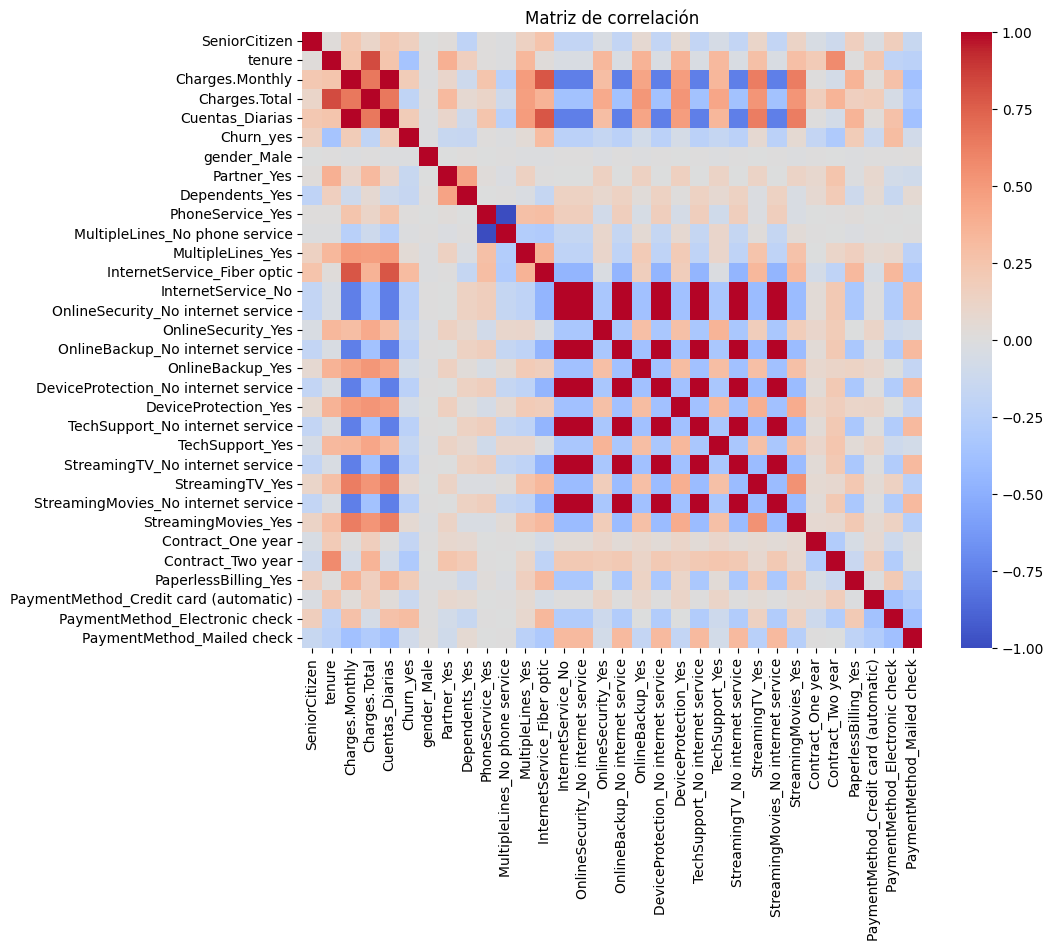

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

In [10]:
X = df.drop(columns=["Churn_yes"])
y = df["Churn_yes"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.7967306325515281
              precision    recall  f1-score   support

       False       0.84      0.89      0.87      1033
        True       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



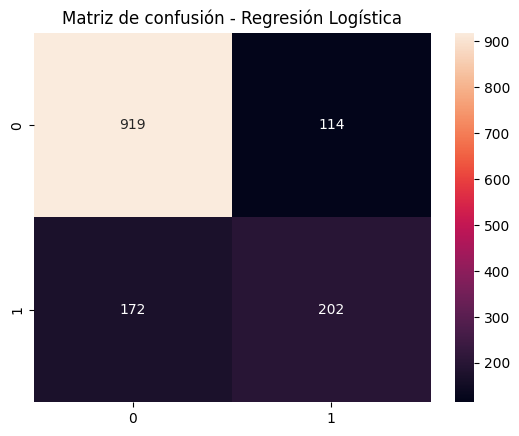

In [15]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

In [16]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7889125799573561
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [18]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

,0
Charges.Total,0.168522
tenure,0.161699
Charges.Monthly,0.126442
Cuentas_Diarias,0.125957
InternetService_Fiber optic,0.037010
PaymentMethod_Electronic check,0.035108
Contract_Two year,0.032625
gender_Male,0.024122
PaperlessBilling_Yes,0.023155
OnlineSecurity_Yes,0.022246


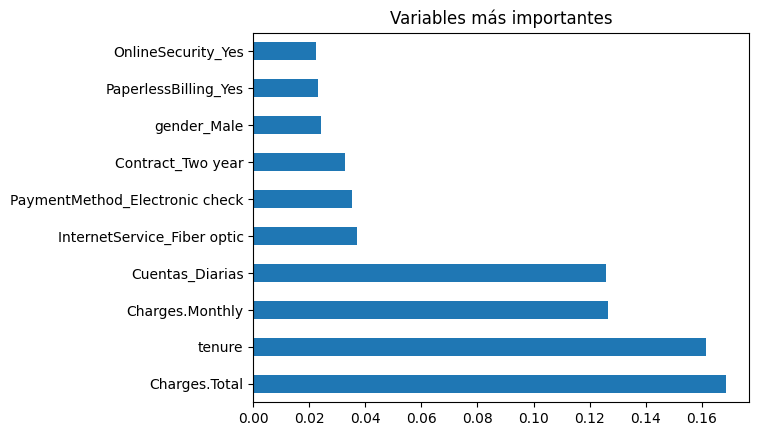

In [19]:
importances.head(10).plot(kind="barh")
plt.title("Variables más importantes")
plt.show()

In [20]:
results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Modelo,Accuracy
0,Logistic Regression,0.796731
1,Random Forest,0.788913


Conclusiones

Los modelos desarrollados permitieron identificar factores asociados
a la cancelación de clientes.

Variables como tipo de contrato, cargos mensuales y tiempo de permanencia
mostraron una influencia significativa en la cancelación.

El modelo Random Forest mostró mejor desempeño en la predicción del churn,
lo que puede ayudar a Telecom X a anticipar cancelaciones y diseñar
estrategias de retención de clientes.